# Data analysis for building Uni-Mea models

## 0. Load

In [1]:
# Trial
import pandas as pd
pd.read_csv('./QMdata4ML/df_elec_x_with_name_fold.csv',index_col=0,nrows=5)

,smiles,elec_sites,elec_names,MAA_values,elec_GCS_3_cm5,Set,elec_SMI2GCS_3_cm5,elec_SMI2GCS_5_cm5,elec_RDKitCountFP_512,elec_RDKitGasteigerGCS_5,...,Set_fold2,Set_fold3,Set_fold4,Set_fold5,Set_cpbased,Set_cpbased_fold1,Set_cpbased_fold2,Set_cpbased_fold3,Set_cpbased_fold4,Set_cpbased_fold5
0,NOCc1cccc(I)c1,3,double_bond,90.348433,"[-0.01706, 0.12057, -0.11146, -0.08969, 0.0, -...",Train_fold5,"[-0.00668, 0.12661, -0.09866, -0.09247, 0.0, -...","[-0.00668, 0.12661, -0.09866, -0.09247, 0.0, -...","[4, 0, 4, 5, 2, 3, 0, 4, 3, 6, 0, 6, 4, 1, 0, ...","[-0.01928812973227673, 0.0929936027236162, -0....",...,train,train,train,val,train_fold1,val,train,train,train,train
1,NOCc1cccc(I)c1,4,double_bond,94.924314,"[-0.08969, -0.01706, -0.08484, 0.09939, 0.0, 0...",Train_fold2,"[-0.09247, -0.00668, -0.07901, 0.0887, 0.0, 0....","[-0.09247, -0.00668, -0.07901, 0.0887, 0.0, 0....","[4, 0, 4, 7, 0, 1, 0, 4, 1, 6, 0, 4, 4, 1, 0, ...","[-0.056572952259338685, -0.01928812973227673, ...",...,val,train,train,train,train_fold1,val,train,train,train,train
2,NOCc1cccc(I)c1,5,double_bond,91.330269,"[-0.08484, -0.10499, -0.08969, 0.09122, 0.0, 0...",Train_fold3,"[-0.07901, -0.09933, -0.09247, 0.08588, 0.0, 0...","[-0.07901, -0.09933, -0.09247, 0.08588, 0.0, 0...","[2, 0, 4, 7, 0, 3, 0, 4, 2, 3, 0, 5, 2, 0, 0, ...","[-0.060854479918004876, -0.04882194239545837, ...",...,train,val,train,train,train_fold1,val,train,train,train,train
3,NOCc1cccc(I)c1,6,double_bond,102.683928,"[-0.10499, 0.01492, -0.08484, 0.08707, 0.0, 0....",Train_fold1,"[-0.09933, 0.00749, -0.07901, 0.08466, 0.0, 0....","[-0.09933, 0.00749, -0.07901, 0.08466, 0.0, 0....","[0, 0, 5, 6, 0, 3, 0, 4, 2, 1, 0, 7, 3, 0, 0, ...","[-0.04882194239545837, 0.013342809000888595, -...",...,train,train,train,train,train_fold1,val,train,train,train,train
4,NOCc1cccc(I)c1,7,double_bond,276.204538,"[0.01492, 0.00479, -0.11146, -0.10499, 0.0, 0....",Train_fold3,"[0.00749, 0.01751, -0.09866, -0.09933, 0.0, 0....","[0.00749, 0.01751, -0.09866, -0.09933, 0.0, 0....","[2, 0, 5, 6, 2, 3, 0, 4, 3, 2, 0, 6, 3, 0, 0, ...","[0.013342809000888595, -0.04430373540190993, -...",...,train,val,train,train,train_fold1,val,train,train,train,train


In [3]:
# Load
df_elec = pd.read_csv('./QMdata4ML/df_elec_x_with_name_fold.csv',index_col=0)
df_nuc  = pd.read_csv('./QMdata4ML/df_nuc_x_with_name_fold.csv',index_col=0)

## 1. Reference split (from the paper written by [Ree et. al.](https://doi.org/10.1039/D4SC07297A))

Basic analysis (count entries and sites for each fold)

In [4]:
print('===Electrophilicity===')
display(df_elec['Set'].value_counts())
display(df_elec.groupby(['Set', 'elec_names']).size().unstack(fill_value=0) )
print('\n===Nucleophilicity===')
display(df_nuc['Set'].value_counts())
display(df_nuc.groupby(['Set', 'nuc_names']).size().unstack(fill_value=0) )

===Electrophilicity===


Train_fold1    90801
Train_fold5    90800
Train_fold2    90800
Train_fold3    90800
Train_fold4    90800
Test           80118
Name: Set, dtype: int64

elec_names,Aldehyde,Amide,Anhydride,Ester,Imine,Iminium,Ketone,Michael acceptor,cation_with_charge_plus1,double_bond,double_bond_neighbouratom_with_charge_plus1,triple_bond
Set,,,,,,,,,,,,
Test,27,1799,3,609,1241,35,524,367,309,74246,284,674
Train_fold1,31,2095,4,698,1409,28,636,407,348,84046,324,775
Train_fold2,35,1973,8,745,1461,22,664,404,319,84103,310,756
Train_fold3,41,2024,2,708,1432,26,653,369,319,84074,350,802
Train_fold4,37,2029,5,715,1383,37,647,400,334,84051,335,827
Train_fold5,38,1996,6,738,1436,26,624,400,326,84133,312,765



===Nucleophilicity===


Train_fold3    110646
Train_fold1    110646
Train_fold2    110646
Train_fold4    110645
Train_fold5    110645
Test            97629
Name: Set, dtype: int64

nuc_names,Aldehyde,Amide,Amine,Carbanion,Carboxylic acid,Ester,Ether,Imine,Isonitrile,Ketone,Nitranion,Nitrile,Phenol,Pyridine_like_nitrogen,anion_with_charge_minus1,atom_with_lone_pair,double_bond,double_bond_neighbouratom_with_charge_plus1,triple_bond
Set,,,,,,,,,,,,,,,,,,,
Test,36,1969,7409,0,306,593,3820,1312,2,656,0,84,611,5042,362,14470,60749,36,172
Train_fold1,49,2189,8383,0,318,688,4219,1440,7,775,0,92,657,5741,438,16671,68759,22,198
Train_fold2,33,2240,8297,0,381,687,4326,1486,9,756,1,83,678,5721,463,16686,68554,39,206
Train_fold3,48,2190,8408,1,383,627,4311,1467,3,789,0,86,686,5737,451,16485,68720,24,230
Train_fold4,43,2242,8259,0,380,641,4283,1452,2,820,0,103,707,5754,446,16577,68674,33,229
Train_fold5,46,2200,8374,1,392,651,4233,1445,4,767,1,89,682,5739,454,16725,68590,27,225


Distribution of target values

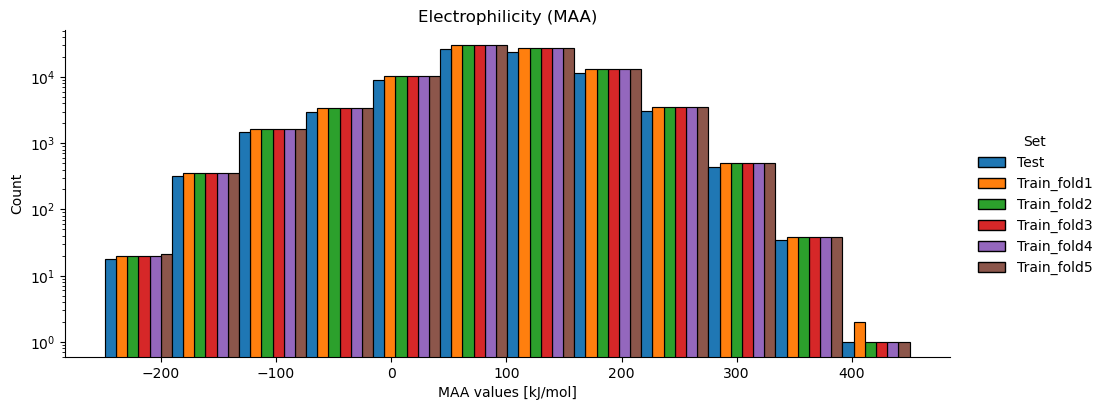

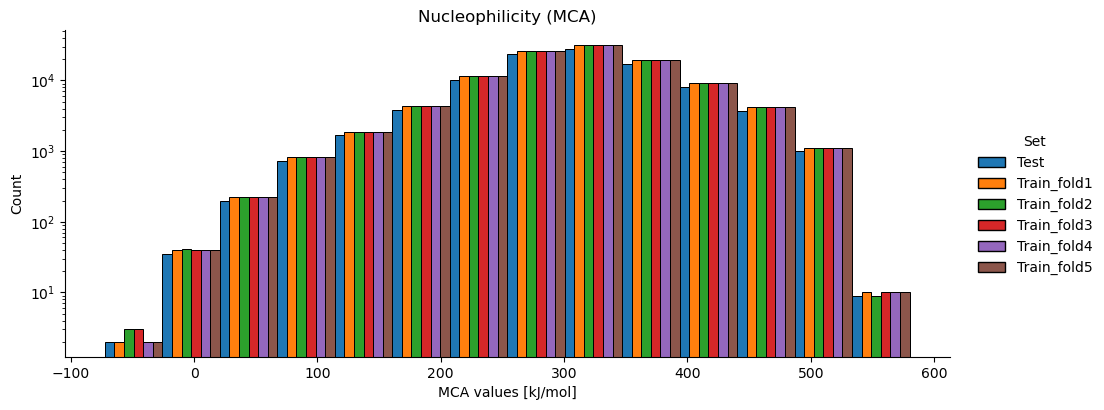

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def roundUpToMultiple(number, multiple):
    num = number + (multiple - 1)
    return num - (num % multiple)

nbins = 13
bins = np.linspace(df_elec['MAA_values'].min(), roundUpToMultiple(df_elec['MAA_values'].max(), 10), nbins)

sns.displot(data=df_elec.sort_values(by='Set'), x='MAA_values', hue='Set', multiple="dodge", alpha=1, bins=bins, height=4, aspect=2.5)
plt.xlabel('MAA values [kJ/mol]')
plt.yscale('log')
plt.title('Electrophilicity (MAA)')
plt.show()

nbins = 15
bins = np.linspace(df_nuc['MCA_values'].min(), roundUpToMultiple(df_nuc['MCA_values'].max(), 10), nbins)

sns.displot(data=df_nuc.sort_values(by='Set'), x='MCA_values', hue='Set', multiple="dodge", alpha=1, bins=bins, height=4, aspect=2.5)
plt.xlabel('MCA values [kJ/mol]')
plt.yscale('log')
plt.title('Nucleophilicity (MCA)')
plt.show()


## 2. Compound-based split

Basic analysis (count entries and sites for each fold)

In [5]:
print('===Electrophilicity===')
display(df_elec['Set_cpbased'].value_counts())
display(df_elec.groupby(['Set_cpbased', 'elec_names']).size().unstack(fill_value=0) )
print('\n===Nucleophilicity===')
display(df_nuc['Set_cpbased'].value_counts())
display(df_nuc.groupby(['Set_cpbased', 'nuc_names']).size().unstack(fill_value=0) )

===Electrophilicity===


train_fold4    91383
train_fold5    91250
train_fold2    91029
train_fold3    90472
train_fold1    90380
test           79605
Name: Set_cpbased, dtype: int64

elec_names,Aldehyde,Amide,Anhydride,Ester,Imine,Iminium,Ketone,Michael acceptor,cation_with_charge_plus1,double_bond,double_bond_neighbouratom_with_charge_plus1,triple_bond
Set_cpbased,,,,,,,,,,,,
test,45,1768,2,638,1274,24,574,356,297,73676,284,667
train_fold1,35,2013,2,710,1444,42,670,414,331,83571,327,821
train_fold2,39,2115,3,692,1381,23,630,386,344,84304,344,768
train_fold3,28,1947,9,731,1402,31,630,410,329,83851,316,788
train_fold4,24,2027,8,704,1431,21,619,365,330,84722,324,808
train_fold5,38,2046,4,738,1430,33,625,416,324,84529,320,747



===Nucleophilicity===


train_fold2    111149
train_fold5    111041
train_fold4    111033
train_fold3    110624
train_fold1    110343
test            96667
Name: Set_cpbased, dtype: int64

nuc_names,Aldehyde,Amide,Amine,Carbanion,Carboxylic acid,Ester,Ether,Imine,Isonitrile,Ketone,Nitranion,Nitrile,Phenol,Pyridine_like_nitrogen,anion_with_charge_minus1,atom_with_lone_pair,double_bond,double_bond_neighbouratom_with_charge_plus1,triple_bond
Set_cpbased,,,,,,,,,,,,,,,,,,,
test,57,1953,7359,0,351,624,3690,1313,4,693,1,85,567,5026,386,14549,59830,26,153
train_fold1,38,2194,8217,1,374,690,4399,1475,5,806,1,107,714,5652,470,16463,68487,43,207
train_fold2,43,2333,8396,0,346,611,4249,1423,4,759,0,77,751,5646,446,16851,68961,22,231
train_fold3,30,2123,8462,1,327,654,4267,1448,2,782,0,92,691,5646,427,16686,68752,33,201
train_fold4,39,2207,8289,0,368,625,4325,1476,5,765,0,103,638,5742,445,16482,69251,25,248
train_fold5,48,2220,8407,0,394,683,4262,1467,7,758,0,73,660,6022,440,16583,68765,32,220


Distribution of target values

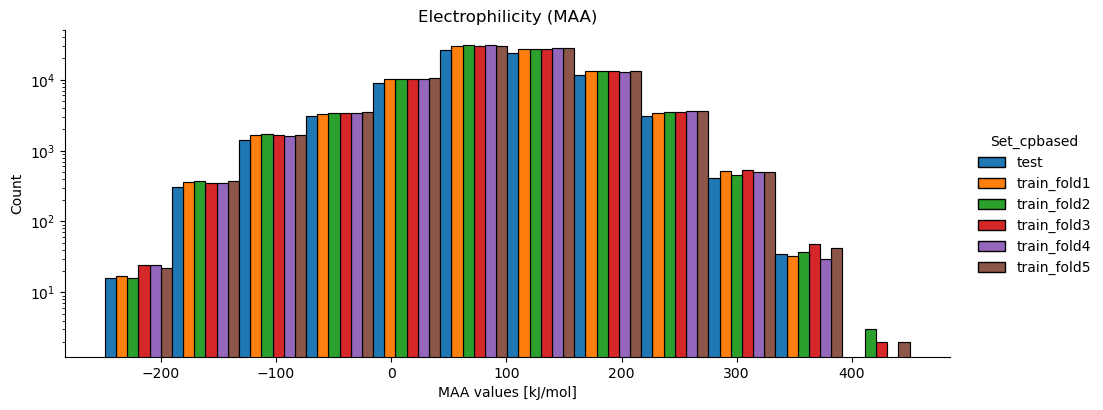

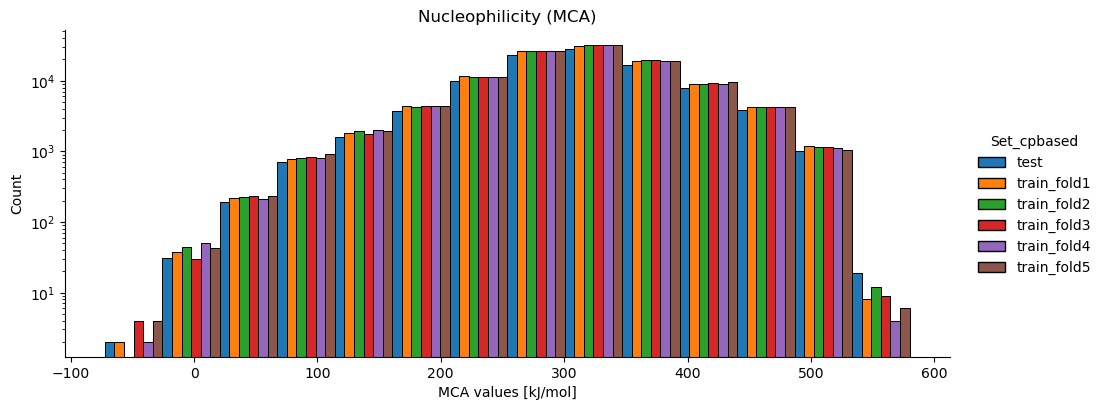

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def roundUpToMultiple(number, multiple):
    num = number + (multiple - 1)
    return num - (num % multiple)

nbins = 13
bins = np.linspace(df_elec['MAA_values'].min(), roundUpToMultiple(df_elec['MAA_values'].max(), 10), nbins)

sns.displot(data=df_elec.sort_values(by='Set_cpbased'), x='MAA_values', hue='Set_cpbased', multiple="dodge", alpha=1, bins=bins, height=4, aspect=2.5)
plt.xlabel('MAA values [kJ/mol]')
plt.yscale('log')
plt.title('Electrophilicity (MAA)')
plt.show()

nbins = 15
bins = np.linspace(df_nuc['MCA_values'].min(), roundUpToMultiple(df_nuc['MCA_values'].max(), 10), nbins)

sns.displot(data=df_nuc.sort_values(by='Set_cpbased'), x='MCA_values', hue='Set_cpbased', multiple="dodge", alpha=1, bins=bins, height=4, aspect=2.5)
plt.xlabel('MCA values [kJ/mol]')
plt.yscale('log')
plt.title('Nucleophilicity (MCA)')
plt.show()
